In [2]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

In [3]:
def group_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    files_per_alpha = {}
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            alpha = float(match.group(3))
            if alpha not in files_per_alpha:
                files_per_alpha[alpha] = [file]
            else:
                files_per_alpha[alpha].append(file)
    # Load the results
    results = pd.DataFrame()
    for alpha, files in files_per_alpha.items():
        for file in files:
            curr_results = pd.read_csv(dir_path + file)
            curr_results['alpha'] = alpha
            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum'}) \
        .reset_index()
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / grouped_results_run_iter.groupby(['alpha', 'Iteration']).count().reset_index()['clicks']
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / grouped_results_run_iter.groupby(['alpha', 'Iteration']).count().reset_index()['true_clicks']
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / grouped_results_run_iter.groupby(['alpha', 'Iteration']).count().reset_index()['impressions']
    # Calcolo CTR e True CTR
    grouped_results['ctr'] = grouped_results['clicks'] / grouped_results['impressions']
    grouped_results['true_ctr'] = grouped_results['true_clicks'] / grouped_results['impressions']
    return grouped_results

In [4]:
dir_path = '../results/FP_Truthful_Oracle_sigmoids_cucb_700iter_10run/'

In [5]:
grouped_results = group_data(dir_path)

In [6]:
grouped_results.to_csv(f'{dir_path}grouped_results.csv', index=False)

In [7]:
data_tp = grouped_results[(grouped_results['alpha'] == 1)&(grouped_results['Iteration'] > 1)]

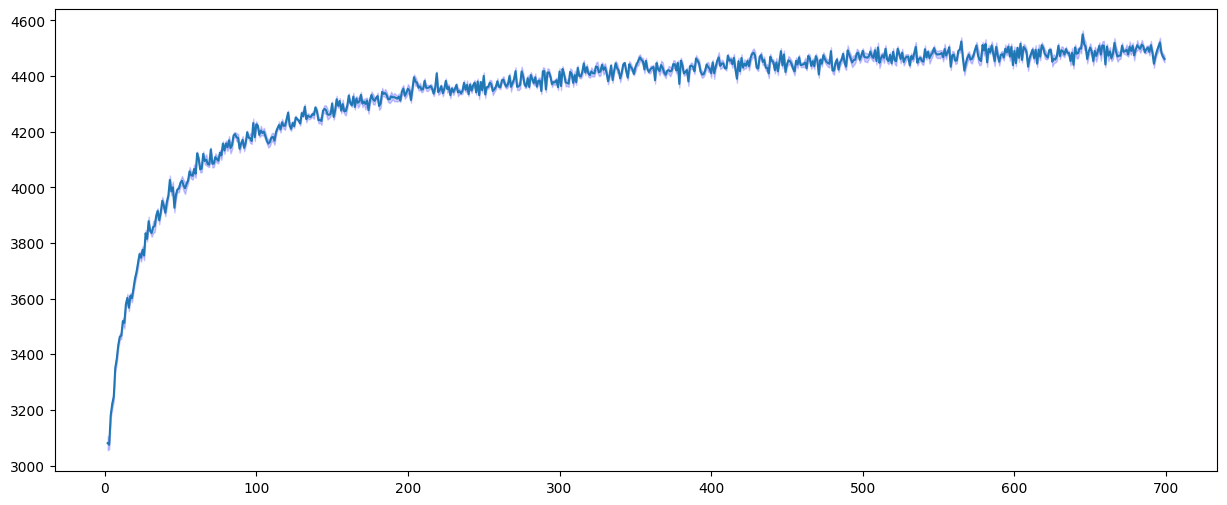

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(data_tp['Iteration'].to_numpy(), data_tp['clicks'].to_numpy())
plt.fill_between(data_tp['Iteration'].to_numpy(), 
                 data_tp['clicks'].to_numpy() -  data_tp['clicks_ci'].to_numpy(), 
                 data_tp['clicks'].to_numpy() +  data_tp['clicks_ci'].to_numpy(), 
                 color='b', alpha=0.2)
plt.show()

LinUCB Truthful bidding - 700 iterazioni e 10 run

In [10]:
linucb_exp_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_700iter_10run/'
linucb_exp = group_data(linucb_exp_path)
linucb_exp = linucb_exp[(linucb_exp['alpha'] == 1)&(linucb_exp['Iteration'] > 1)]

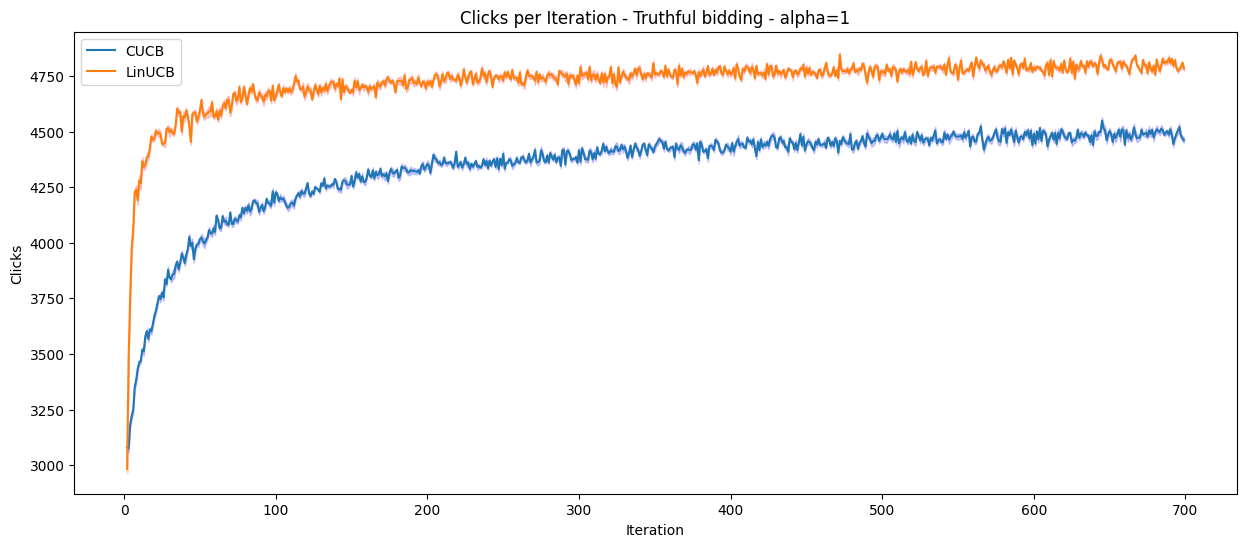

In [16]:
plt.figure(figsize=(15, 6))
plt.plot(data_tp['Iteration'].to_numpy(), data_tp['clicks'].to_numpy(), label='CUCB')
plt.fill_between(data_tp['Iteration'].to_numpy(), 
                 data_tp['clicks'].to_numpy() -  data_tp['clicks_ci'].to_numpy(), 
                 data_tp['clicks'].to_numpy() +  data_tp['clicks_ci'].to_numpy(), 
                 color='b', alpha=0.2)
plt.plot(linucb_exp['Iteration'].to_numpy(), linucb_exp['clicks'].to_numpy(), label='LinUCB')
plt.fill_between(linucb_exp['Iteration'].to_numpy(), 
                 linucb_exp['clicks'].to_numpy() -  linucb_exp['clicks_ci'].to_numpy(), 
                 linucb_exp['clicks'].to_numpy() +  linucb_exp['clicks_ci'].to_numpy(), 
                 color='r', alpha=0.2)
plt.ylabel('Clicks')
plt.xlabel('Iteration')
plt.title('Clicks per Iteration - Truthful bidding - alpha=1')
plt.legend()
plt.show()

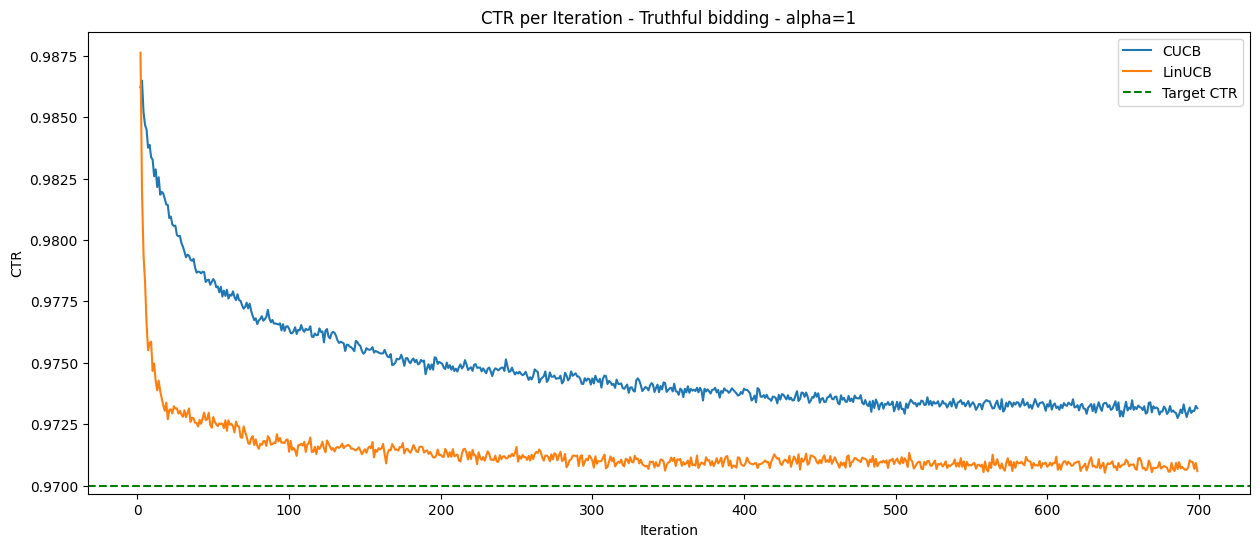

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(data_tp['Iteration'].to_numpy(), data_tp['true_ctr'].to_numpy(), label='CUCB')
plt.plot(linucb_exp['Iteration'].to_numpy(), linucb_exp['true_ctr'].to_numpy(), label='LinUCB')
plt.axhline(y=0.97, color='g', linestyle='--', label='Target CTR')
plt.ylabel('CTR')
plt.xlabel('Iteration')
plt.title('CTR per Iteration - Truthful bidding - alpha=1')
plt.legend()
plt.show()